In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import rateslib as rl
import QuantLib as ql

import datetime
import pytz

NYC_tz = pytz.timezone("America/New_York") 

import sys
sys.path.append("../../")

In [2]:
from MDP.STIRFutures.STIRFutureOptionMDP import STIRFutureOptionMDP
from Query.STIRFutureOptions.STIRFutureOptionQuery import STIRFutureOptionQuery
from Query.STIRFutureOptions.STIRFutureOptionStructure import STIRFutureOptionStructure
from Query.STIRFutureOptions.STIRFutureOptionValue import STIRFutureOptionValue

In [3]:
stirfo_mdp = STIRFutureOptionMDP(source="BARCHART_STIRFO-QL")

In [6]:
as_of = datetime.date(2026, 5, 29)
# as_of = "live"

q = STIRFutureOptionQuery(
    structure=STIRFutureOptionStructure.OUTRIGHT,
    value=STIRFutureOptionValue.PRICE,
    symbol="SFRZ26|ATMS",  
    market_request={
        "endpoint": "option_snapshot",
        "timestamp": as_of,
        "use_ql_calculator": True,
        # "force_refresh": True,
    },
)

req = q.build_mdp_request(as_of)
pr = stirfo_mdp.get_pricer(req)

package, weights = q.resolve_package(pricer_or_curve=pr)
value_map = q.build_value_map(
    pricer_or_curve=pr,
    package=package,
    risk_weights=weights,
)

print("resolved_symbol:", package[0].symbol())
print("price:", value_map.apply(STIRFutureOptionValue.PRICE))
print("iv_normal_bps:", value_map.apply(STIRFutureOptionValue.IV_NORMAL_BPS))
print("delta:", value_map.apply(STIRFutureOptionValue.DELTA))
print("gamma:", value_map.apply(STIRFutureOptionValue.GAMMA))
print("vega:", value_map.apply(STIRFutureOptionValue.VEGA))
print("theta:", value_map.apply(STIRFutureOptionValue.THETA))

resolved_symbol: SFRZ26|9625S
price: 0.405
iv_normal_bps: 68.97875858931103
delta: -0.12167244140033268
gamma: 1.5085617225564816
vega: 0.5730259760708791
theta: -0.34379223467326614


In [8]:
from RVUtils.ImpliedDistribution import (
    SFRImpliedDistribution,
    FedScenarioConfig,
    plot_snapshot_dashboard,
    plot_rnd_comparison,
	plot_distribution_change,
	resolve_strip_symbols,
    plot_strip_distribution_change,
    plot_sfr_smile
)


# config = FedScenarioConfig.default_sofr_scenarios(
#     current_rate=3.64, n_cuts_range=[-1, 0, 1, 2, 3]
# )
# dist = SFRImpliedDistribution(scenario_config=config)

# smile1 = stirfo_mdp.fetch_sabr_smile({
#     "symbol": "SFRZ26",
#     "as_of": datetime.date(2026, 5, 22),
#     # "strike_offsets_bps": "listed",
#     # "force_refresh": True,
#     "show_tqdm": True,
# })
# plot_sfr_smile(smile1)

# smile2 = stirfo_mdp.fetch_sabr_smile({
#     "symbol": "SFRM27",
#     "as_of": datetime.date(2026, 3, 3),
#     # "as_of": "live", 
#     # "strike_offsets_bps": "listed",
#     "show_tqdm": True,
# })
# plot_sfr_smile(smile2)

# snap_before, snap_after = dist.compare(smile1, smile2)
# fig = plot_distribution_change(snap_before, snap_after)

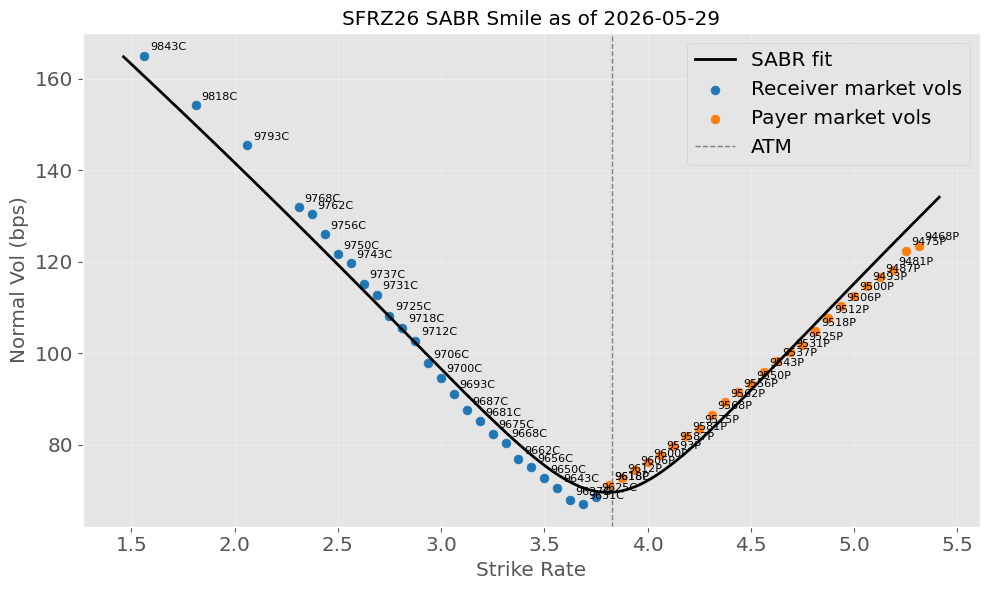

c:\Users\chris\clee\ARBS\notebooks\pricers\../..\RVUtils\ImpliedDistribution\implied_distribution.py:170: UserWarning:

Raw market filtering left only 0 points (need >=2); falling back to SABR vol evaluation at listed strikes.



mean: 3.804428248851871
median: 3.823467802454339
5th: 3.055473514916773
95th: 4.522197310353345
bin edges: [1.25 1.5  1.75 2.   2.25 2.5  2.75 3.   3.25 3.5  3.75 4.   4.25 4.5
 4.75 5.   5.25 5.5  5.75 6.  ]
bin probabilities: [0.         0.0021959  0.00716888 0.00873138 0.00670961 0.00302191
 0.01451663 0.0500073  0.11360823 0.21136325 0.26223597 0.18231365
 0.07612515 0.0161711  0.01233119 0.01712603 0.00687495 0.
 0.        ]


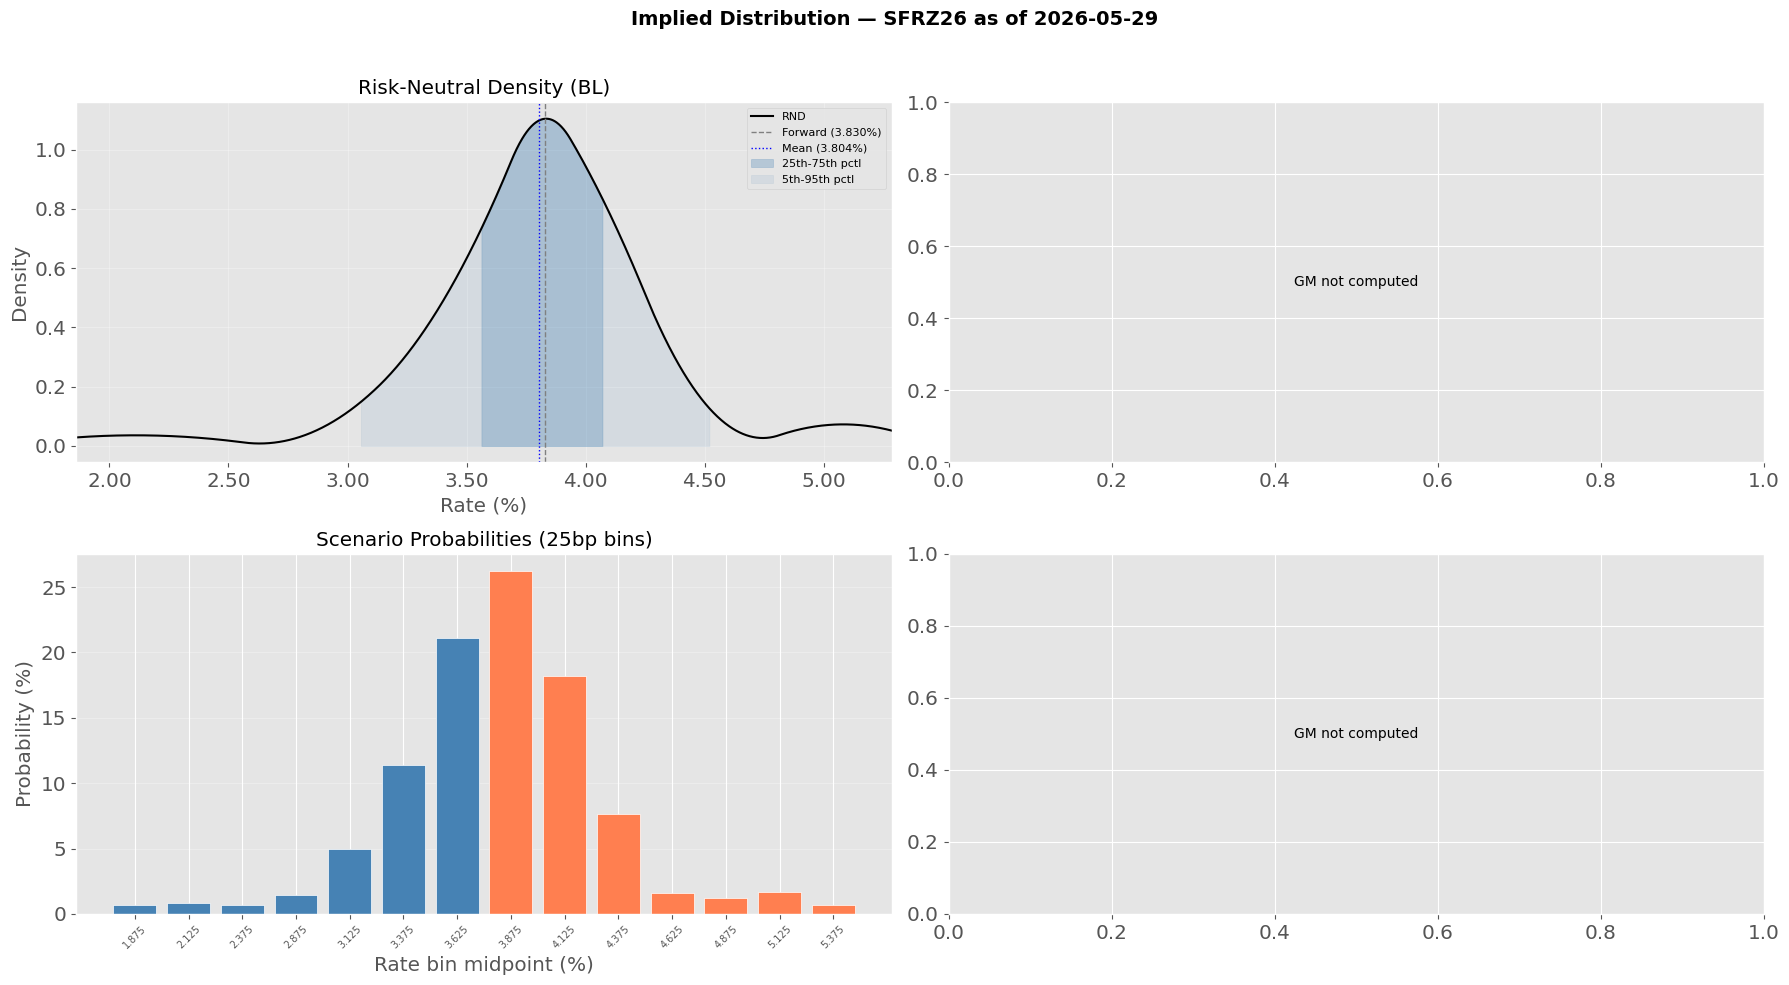

In [10]:
from RVUtils.ImpliedDistribution import SFRImpliedDistribution, plot_snapshot_dashboard

smile = stirfo_mdp.fetch_sabr_smile({
    "symbol": "SFRZ26",
    "as_of": datetime.date(2026, 5, 29),
    "strike_offsets_bps": "listed",
    "show_tqdm": True,
})
plot_sfr_smile(smile)

# Default is raw JPM-style BL:
# observed OTM premiums, OI >= 100, put-call parity, 25bp bins
dist = SFRImpliedDistribution()

snapshot = dist.extract(smile)
bl = snapshot.bl_result

print("mean:", bl.mean_rate)
print("median:", bl.percentile(50))
print("5th:", bl.percentile(5))
print("95th:", bl.percentile(95))
print("bin edges:", bl.bin_edges_rate)
print("bin probabilities:", bl.bin_probabilities)

a = plot_snapshot_dashboard(snapshot)

In [42]:
bl.percentile(95)

4.6151735072297395